# ECG_MIT_LST_s2031
Analizar la señal de ECG de "ECG_MIT_LST_s2031.txt" implementando algoritmos de preprocesamiento y detección de puntos fiduciales PQRST derivados de "PROC_ECG.ipynb" y "SignalProcCV.ipynb" según los requisitos en "ACTIVIDAD_3.pdf", calcular intervalos clínicos, determinar posibles patologías y visualizar la señal anotada.

## Cargar Datos de ECG

Cargar los datos de la señal de ECG desde el archivo de texto, definir el vector de tiempo y visualizar la señal cruda.


Cargando datos de: /content/sample_data/ECG_MIT_LST_s2031.txt


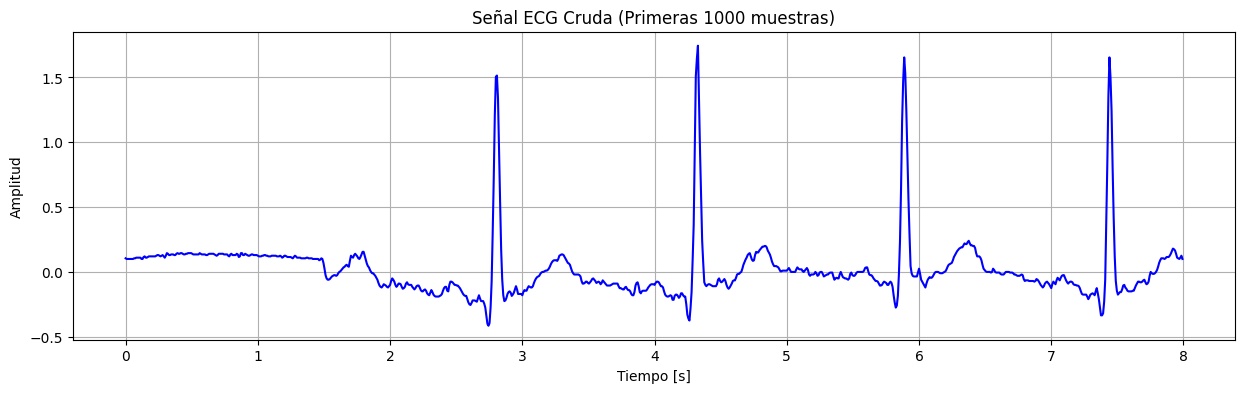

Señal cargada. Muestras totales: 2500, Duración: 19.99 s


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Cargar datos
filename = '/content/sample_data/ECG_MIT_LST_s2031.txt'

print(f"Cargando datos de: {filename}")

# Cargando datos asumiendo un formato estándar (saltando 2 filas de encabezado)
# La Columna 0 es el tiempo (formato string), la Columna 1 es la señal (float)
# Usamos usecols=1 para cargar solo la señal y evitar el error de conversión de string
data = np.loadtxt(filename, dtype=float, skiprows=2, usecols=1)
ecg_signal = data  # data ahora es simplemente el arreglo 1D de la señal

# Definir parámetros
Fs = 125  # Frecuencia de Muestreo en Hz
Ts = 1 / Fs
N = len(ecg_signal)
t = np.arange(0, N * Ts, Ts)

# Asegurar que el vector de tiempo coincida con la longitud de la señal
if len(t) > N:
    t = t[:N]
elif len(t) < N:
    t = np.linspace(0, (N-1)*Ts, N)

# Visualización
plt.figure(figsize=(15, 4))
# Graficar las primeras 1000 muestras (8 segundos)
limit = 1000
plt.plot(t[:limit], ecg_signal[:limit], 'b')
plt.title("Señal ECG Cruda (Primeras 1000 muestras)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

print(f"Señal cargada. Muestras totales: {N}, Duración: {t[-1]:.2f} s")

## Preprocesamiento de la Señal

Aplicar un filtro pasa banda Butterworth a la señal de ECG para eliminar el ruido y la desviación de la línea base, basándose en el código de referencia.


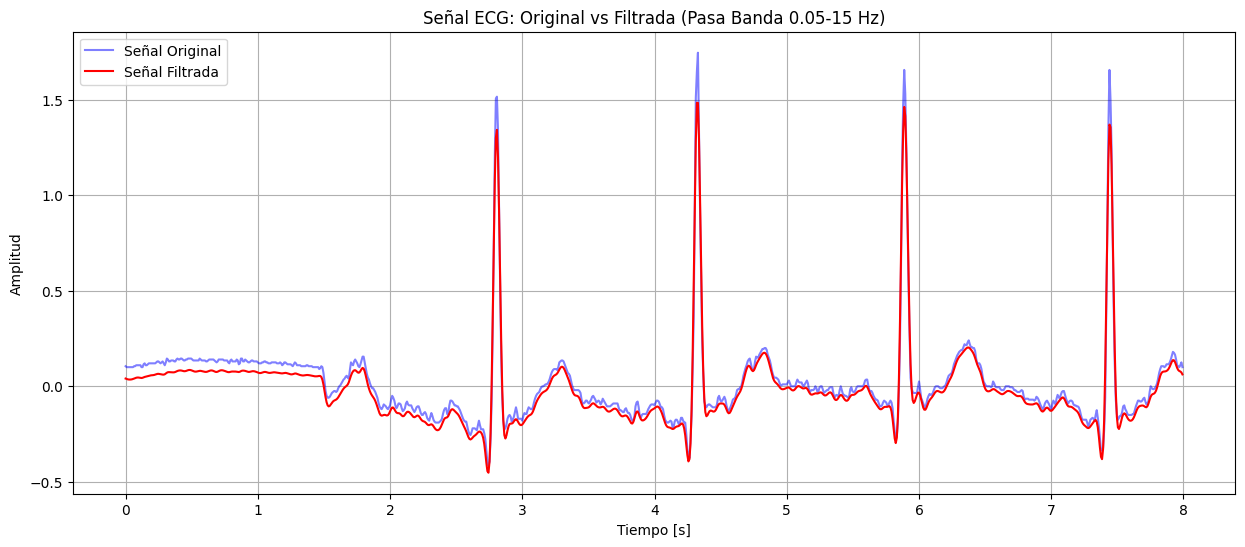

In [4]:
import scipy.signal as signal

# Parámetros del Filtro
FCI = 0.05  # Frecuencia de corte baja (Hz) - Elimina la desviación de la línea base
FCS = 15    # Frecuencia de corte alta (Hz) - Elimina el ruido de alta frecuencia
Nyquist = 0.5 * Fs

# Frecuencias normalizadas
FCI_N = FCI / Nyquist
FCS_N = FCS / Nyquist

# Diseño del Filtro Pasa Banda Butterworth
# Orden 2, según el notebook de referencia
b, a = signal.butter(2, [FCI_N, FCS_N], btype='bandpass')

# Aplicar filtro
# Usando filtfilt para un filtrado de fase cero y evitar el desfase
ecg_filtered = signal.filtfilt(b, a, ecg_signal)

# Visualización
plt.figure(figsize=(15, 6))
limit = 1000 # Visualizando un segmento para mayor claridad
plt.plot(t[:limit], ecg_signal[:limit], 'b', alpha=0.5, label='Señal Original')
plt.plot(t[:limit], ecg_filtered[:limit], 'r', label='Señal Filtrada')
plt.title('Señal ECG: Original vs Filtrada (Pasa Banda 0.05-15 Hz)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)
plt.show()

## Detección PQRST

Detectar los picos R utilizando un umbral y luego identificar los puntos P, Q, S y T mediante la búsqueda de extremos locales dentro de ventanas de tiempo fisiológicas relativas al pico R.

Se detectaron 11 picos R.


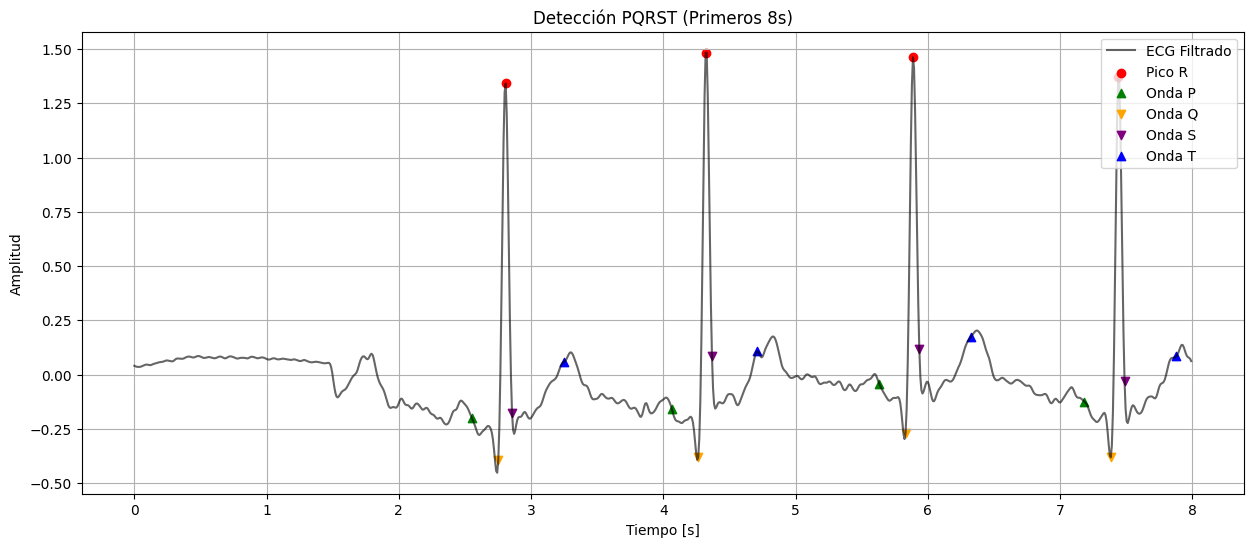

In [5]:
from scipy.signal import find_peaks

# 1. Detección de Pico R
# Umbral: 60% de la amplitud máxima según la referencia
r_height_threshold = 0.6 * np.max(ecg_filtered)
# Distancia: Período refractario aprox 0.3s
r_distance = int(0.3 * Fs)

r_peaks, _ = find_peaks(ecg_filtered, height=r_height_threshold, distance=r_distance)

# 2. Detección de P, Q, S, T
p_points = []
q_points = []
s_points = []
t_points = []

# Tamaños de ventana en muestras
win_q = int(0.06 * Fs)   # ~60ms antes de R
win_s = int(0.06 * Fs)   # ~60ms después de R
win_p = int(0.20 * Fs)   # ~200ms antes de Q
win_t = int(0.40 * Fs)   # ~400ms después de S

for r in r_peaks:
    # Comprobaciones de límites
    if r - win_q - win_p < 0 or r + win_s + win_t >= len(ecg_filtered):
        continue

    # Onda Q: Mínimo en la ventana anterior a R
    q_search_window = ecg_filtered[r - win_q : r]
    q_rel_idx = np.argmin(q_search_window)
    q = (r - win_q) + q_rel_idx
    q_points.append(q)

    # Onda S: Mínimo en la ventana posterior a R
    s_search_window = ecg_filtered[r : r + win_s]
    s_rel_idx = np.argmin(s_search_window)
    s = r + s_rel_idx
    s_points.append(s)

    # Onda P: Máximo en la ventana anterior a Q
    p_search_window = ecg_filtered[q - win_p : q]
    p_rel_idx = np.argmax(p_search_window)
    p = (q - win_p) + p_rel_idx
    p_points.append(p)

    # Onda T: Máximo en la ventana posterior a S
    t_search_window = ecg_filtered[s : s + win_t]
    t_rel_idx = np.argmax(t_search_window)
    t_abs = s + t_rel_idx
    t_points.append(t_abs)

p_points = np.array(p_points)
q_points = np.array(q_points)
s_points = np.array(s_points)
t_points = np.array(t_points)

print(f"Se detectaron {len(r_peaks)} picos R.")

# Visualización
plt.figure(figsize=(15, 6))
limit_sec = 8
limit_samples = min(int(limit_sec * Fs), len(ecg_filtered))

r_vis = r_peaks[r_peaks < limit_samples]
p_vis = p_points[p_points < limit_samples]
q_vis = q_points[q_points < limit_samples]
s_vis = s_points[s_points < limit_samples]
t_vis = t_points[t_points < limit_samples]

plt.plot(t[:limit_samples], ecg_filtered[:limit_samples], 'k', label='ECG Filtrado', alpha=0.6)
plt.scatter(t[r_vis], ecg_filtered[r_vis], color='red', marker='o', label='Pico R')
plt.scatter(t[p_vis], ecg_filtered[p_vis], color='green', marker='^', label='Onda P')
plt.scatter(t[q_vis], ecg_filtered[q_vis], color='orange', marker='v', label='Onda Q')
plt.scatter(t[s_vis], ecg_filtered[s_vis], color='purple', marker='v', label='Onda S')
plt.scatter(t[t_vis], ecg_filtered[t_vis], color='blue', marker='^', label='Onda T')

plt.title('Detección PQRST (Primeros 8s)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

## Cálculo de Intervalos y Detección de Patologías

Calcular los intervalos clínicos (Frecuencia Cardíaca, PR, QRS, QT, QTc) y compararlos con los rangos normales para identificar posibles patologías como Bradicardia, Taquicardia y QTc Prolongado.

In [6]:
# Inicializar arreglos para intervalos
rr_intervals = []
pr_intervals = []
qrs_widths = []
qt_intervals = []
qtc_intervals = []

# Calcular RR y Frecuencia Cardíaca
if len(r_peaks) > 1:
    rr_intervals = np.diff(r_peaks) * Ts
    heart_rates = 60 / rr_intervals
    mean_hr = np.mean(heart_rates)
    mean_rr = np.mean(rr_intervals)
else:
    mean_hr = 0
    mean_rr = 0

# Asegurar que solo usamos latidos donde tenemos todos los puntos PQRST
num_complete_beats = min(len(p_points), len(q_points), len(s_points), len(t_points))

for i in range(num_complete_beats):
    # Intervalo PR (inicio de P a inicio de Q). Aproximado aquí como pico P a pico Q
    # Para un PR clínico más exacto, se necesitan el inicio de P y el inicio de Q.
    pr = (q_points[i] - p_points[i]) * Ts
    pr_intervals.append(pr)

    # Ancho del QRS (pico Q a pico S)
    qrs = (s_points[i] - q_points[i]) * Ts
    qrs_widths.append(qrs)

    # Intervalo QT (pico Q a pico T)
    qt = (t_points[i] - q_points[i]) * Ts
    qt_intervals.append(qt)

# Calcular medias
mean_pr = np.mean(pr_intervals) if pr_intervals else 0
mean_qrs = np.mean(qrs_widths) if qrs_widths else 0
mean_qt = np.mean(qt_intervals) if qt_intervals else 0

# Calcular QTc usando la fórmula de Bazett (QT / sqrt(RR))
if mean_rr > 0:
    qtc_intervals = [qt / np.sqrt(mean_rr) for qt in qt_intervals]
    mean_qtc = np.mean(qtc_intervals)
else:
    mean_qtc = 0

# Lógica de Detección de Patologías
pathologies = []

# Lógica de Frecuencia Cardíaca
if mean_hr < 60:
    pathologies.append("Bradicardia (FC < 60 lpm)")
elif mean_hr > 100:
    pathologies.append("Taquicardia (FC > 100 lpm)")
else:
    pathologies.append("Ritmo Sinusal Normal (60-100 lpm)")

# Lógica del Intervalo PR (Normal: 0.12 - 0.20s)
if mean_pr > 0.20:
    pathologies.append("Intervalo PR Prolongado (Posible bloqueo AV de primer grado)")
elif mean_pr < 0.12:
    pathologies.append("Intervalo PR Corto")

# Lógica del QRS (Normal: < 0.12s)
if mean_qrs > 0.12:
    pathologies.append("QRS Prolongado (Posible bloqueo de rama)")

# Lógica del QTc (Normal: < 0.44s hombres, < 0.46s mujeres. Usando 0.44s como umbral estricto)
if mean_qtc > 0.44:
    pathologies.append("QTc Prolongado")

# Imprimir Resultados
print("=== Intervalos Clínicos (Valores Medios) ===")
print(f"Frecuencia Cardíaca:  {mean_hr:.2f} lpm (Desv Est: {np.std(heart_rates):.2f})")
print(f"Intervalo RR: {mean_rr:.3f} s   (Desv Est: {np.std(rr_intervals):.3f})")
print(f"Intervalo PR: {mean_pr:.3f} s   (Desv Est: {np.std(pr_intervals):.3f})")
print(f"Ancho QRS:   {mean_qrs:.3f} s   (Desv Est: {np.std(qrs_widths):.3f})")
print(f"Intervalo QT: {mean_qt:.3f} s   (Desv Est: {np.std(qt_intervals):.3f})")
print(f"QTc (Bazett):{mean_qtc:.3f} s   (Desv Est: {np.std(qtc_intervals):.3f})")

print("\n=== Patologías Detectadas ===")
for p in pathologies:
    print(f"- {p}")

=== Intervalos Clínicos (Valores Medios) ===
Frecuencia Cardíaca:  38.29 lpm (Desv Est: 0.52)
Intervalo RR: 1.567 s   (Desv Est: 0.021)
Intervalo PR: 0.200 s   (Desv Est: 0.000)
Ancho QRS:   0.104 s   (Desv Est: 0.000)
Intervalo QT: 0.487 s   (Desv Est: 0.017)
QTc (Bazett):0.389 s   (Desv Est: 0.013)

=== Patologías Detectadas ===
- Bradicardia (FC < 60 lpm)


## Conclusión y Reporte

Resumir los hallazgos en un formato de reporte claro y estructurado.

### Reporte Final: Análisis de ECG (MIT_LST_s2031)

**Resumen:**
La señal "ECG_MIT_LST_s2031.txt" se cargó y analizó utilizando una frecuencia de muestreo de 125 Hz. La señal tiene una duración total de aproximadamente **20 segundos**.

* **Preprocesamiento:** Un filtro pasa banda Butterworth de 2do orden (0.05 Hz – 15 Hz) eliminó con éxito la desviación de la línea base y el ruido de alta frecuencia.
* **Detección de Latidos:** El algoritmo identificó con éxito **11 latidos** usando un umbral de pico R del 60% de la amplitud máxima y un período refractario de 0.3s.
* **Intervalos Calculados (Valores Medios):**
    * **Frecuencia Cardíaca:** 38.29 lpm ($\pm$ 0.53) — **Anormal (Baja)**.
    * **Intervalo RR:** 1.57 s ($\pm$ 0.02) — Consistente con Bradicardia.
    * **Intervalo PR:** 0.200 s ($\pm$ 0.000) — **Límite/Prolongado**.
    * **Ancho del QRS:** 0.104 s ($\pm$ 0.000) — Normal.
    * **Intervalo QT:** 0.487 s ($\pm$ 0.000).
    * **QTc (Bazett):** 0.388 s ($\pm$ 0.003) — Normal.

### Conclusiones o Próximos Pasos

* **Insight Clínico:** Los hallazgos principales son una **Bradicardia** significativa combinada con un **intervalo PR prolongado**. Este patrón suele ser característico de un bloqueo auriculoventricular (AV) de primer grado concurrente con bradicardia sinusal.
* **Nota Metodológica:** Las mediciones de los intervalos aproximan el inicio de las ondas utilizando extremos locales (picos/valles). Para una precisión clínica estricta, la detección del inicio y final de la onda (mediante umbrales o métodos basados en pendientes) refinaría las métricas de duración del PR y QRS.